# Exploratory Data Analysis (EDA) Checklist

## Summary of Findings
1. Dataset was loaded successfully into a Pandas DataFrame.
2. Missing values were identified and analyzed.
3. Numeric columns were checked for skewness and outliers.
4. Categorical columns were analyzed using value counts.
5. Histograms, boxplots, and pairplots were generated and saved.

---

In [19]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os

# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

# Optional styling
sns.set_style("whitegrid")

In [20]:
# mysql database connection

from dotenv import load_dotenv

load_dotenv()

mysql_user = 'root'
mysql_password = quote_plus(os.getenv("Password"))
mysql_host = 'localhost'
mysql_port = 3306
mysql_database = 'brewery_db'

try:
    # Use pymysql as the DBAPI for mysqlclient

    
    engine = create_engine(f'mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/{mysql_database}')

    # Check if connection is successful by trying to connect
    with engine.connect() as connection:
        print("Successfully connected to MySQL database.")

except Exception as e:
    print(f"Error connecting to or loading data into MySQL: {e}")
    print("Please ensure MySQL is running and credentials are correct.")

Successfully connected to MySQL database.


In [21]:
# load database from mysql

df = pd.read_sql("select * from breweries", engine)
print(df.head())

print("\nSucessfully loaded into the DataFrame.")

                                     id  \
0  06e9fffb-e820-45c9-b107-b52b51013e8f   
1  08f78223-24f8-4b71-b381-ea19a5bd82df   
2  0faa0fb2-fffa-416d-9eab-46f67477c8ef   
3  1988eb86-f0a2-4674-ba04-02454efa0d31   
4  1a1b2165-73ed-40aa-b89b-56794d140f22   

                                            name brewery_type        city  \
0                               12Degree Brewing      brewpub  Louisville   
1                       11 Below Brewing Company        micro     Houston   
2  12 West Brewing Company - Production Facility        micro        Mesa   
3                  10 Barrel Brewing Co - Denver        large      Denver   
4                           1840 Brewing Company        micro   Milwaukee   

       state        country postal_code                    website_url  \
0   Colorado  United States       80027        http://www.12degree.com   
1      Texas  United States       77066  http://www.11belowbrewing.com   
2    Arizona  United States       85207                 

In [22]:
# dataset shape, information and data types

print("Shape of Dataset: ")
print(df.shape)

print("\nDataset Info: ")
df.info()

print("\nData Types: ")
# print(df.dtypes)
df.dtypes

Shape of Dataset: 
(50, 13)

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                50 non-null     object
 1   name              50 non-null     object
 2   brewery_type      50 non-null     object
 3   city              50 non-null     object
 4   state             50 non-null     object
 5   country           50 non-null     object
 6   postal_code       49 non-null     object
 7   website_url       40 non-null     object
 8   phone             46 non-null     object
 9   name_length       50 non-null     int64 
 10  location          50 non-null     object
 11  has_website       50 non-null     int64 
 12  is_micro_brewery  50 non-null     int64 
dtypes: int64(3), object(10)
memory usage: 5.2+ KB

Data Types: 


id                  object
name                object
brewery_type        object
city                object
state               object
country             object
postal_code         object
website_url         object
phone               object
name_length          int64
location            object
has_website          int64
is_micro_brewery     int64
dtype: object

In [23]:
# missing value and perentage

missing_values = df.isnull().sum()

print("\nMisiing values count: ", missing_values)

missing_percent = (missing_values / len(df)) *100

print("Missing Percentage Per Column: ", missing_percent)



Misiing values count:  id                   0
name                 0
brewery_type         0
city                 0
state                0
country              0
postal_code          1
website_url         10
phone                4
name_length          0
location             0
has_website          0
is_micro_brewery     0
dtype: int64
Missing Percentage Per Column:  id                   0.0
name                 0.0
brewery_type         0.0
city                 0.0
state                0.0
country              0.0
postal_code          2.0
website_url         20.0
phone                8.0
name_length          0.0
location             0.0
has_website          0.0
is_micro_brewery     0.0
dtype: float64


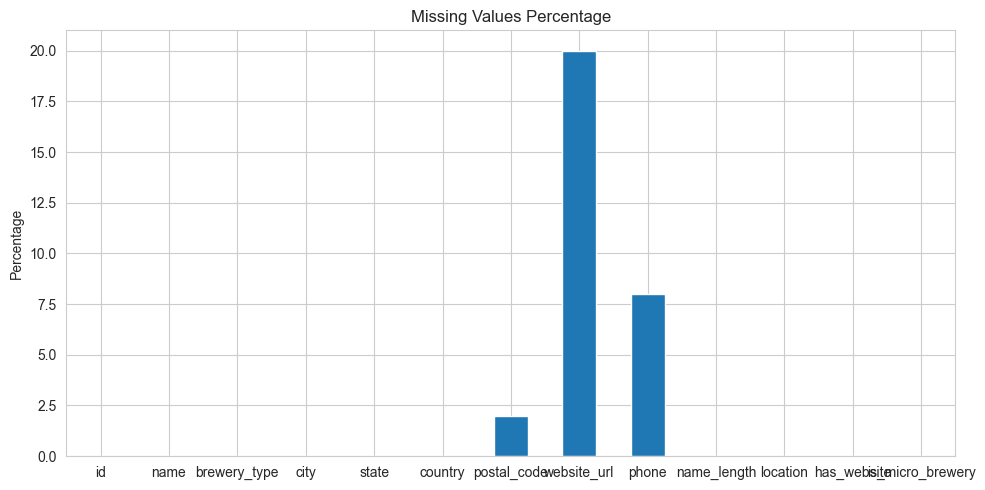

In [24]:
# missing value visualization

plt.figure(figsize=(10,5))

missing_percent.plot(kind='bar')

plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/missing_values.png")

plt.show()

In [25]:
# descriptive statistics

print("\nDescriptive Statistics: ")

df.describe()


Descriptive Statistics: 


,name_length,has_website,is_micro_brewery
count,50.000000,50.000000,50.000000
mean,20.180000,0.800000,0.600000
std,6.166698,0.404061,0.494872
min,10.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000
50%,20.000000,1.000000,1.000000
75%,23.000000,1.000000,1.000000
max,45.000000,1.000000,1.000000


## Observations
1. Compare mean and median values to identify skewness.
2. Check minimum and maximum values for suspicious entries.
3. Large standard deviation may indicate high variance.


Categorical Columns: 
Index(['id', 'name', 'brewery_type', 'city', 'state', 'country', 'postal_code',
       'website_url', 'phone', 'location'],
      dtype='object')
Value Counts for id:

id
06e9fffb-e820-45c9-b107-b52b51013e8f    1
d5cb896d-3e99-4e19-9693-5e06ce987e53    1
85192a9c-58a4-48c3-bd9d-496d09d22aa3    1
896f26a1-d80e-4790-9287-026a86c1799d    1
936c3d7e-5d54-4459-b72c-117cdda059b4    1
950180bd-29c9-46b3-ad0c-e6f09799ec7f    1
9c5a66c8-cc13-416f-a5d9-0a769c87d318    1
9f1852da-c312-42da-9a31-097bac81c4c0    1
add7f978-942e-4d56-b209-c80837a51d69    1
b51f3cdf-60ff-4ae1-94a7-76906c7d62eb    1
b7b68d22-5045-4501-b9bf-ec94946eaffc    1
d35b40b0-a3ff-4878-a6ee-9caa2149b521    1
d81ff708-b5d2-478f-af6a-6d40f5beb9ac    1
08f78223-24f8-4b71-b381-ea19a5bd82df    1
dbde8235-2b55-4d8b-8b1c-438155abe104    1
e2e78bd8-80ff-4a61-a65c-3bfbd9d76ce2    1
e432899b-7f58-455f-9c7b-9a6e2130a1e0    1
e54c2f02-acd6-4172-861d-fcfa54c8701a    1
e5f3e72a-fee2-4813-82cf-f2e53b439ae6    1
ea4f30c0

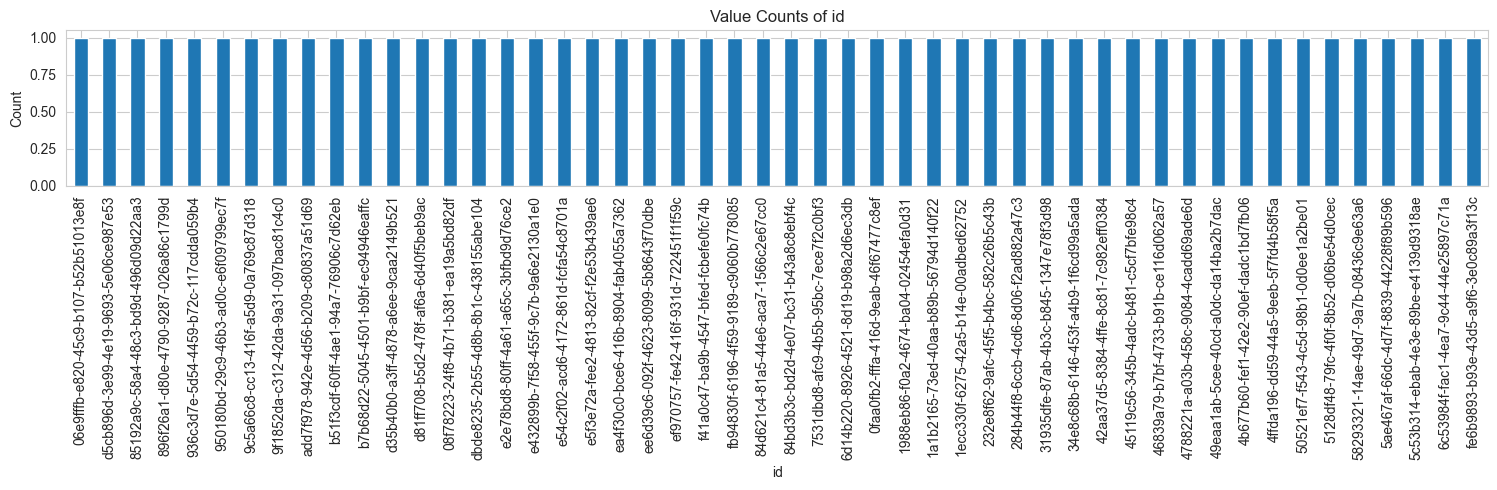

In [26]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns: ")
print(categorical_cols)

# value counts
# Select first categorical column
col = categorical_cols[0]

print(f"Value Counts for {col}:\n")

print(df[col].value_counts())

# value count visualization
plt.figure(figsize=(15,5))

df[col].value_counts().plot(kind='bar')

plt.title(f"Value Counts of {col}")
plt.xlabel(col)
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(f"charts/value_counts_{col}.png")

plt.show()

In [27]:
# numeric columns

numeric_cols = df.select_dtypes(include=np.number).columns

print("Numeric Columns:\n")
print(numeric_cols)

Numeric Columns:

Index(['name_length', 'has_website', 'is_micro_brewery'], dtype='object')


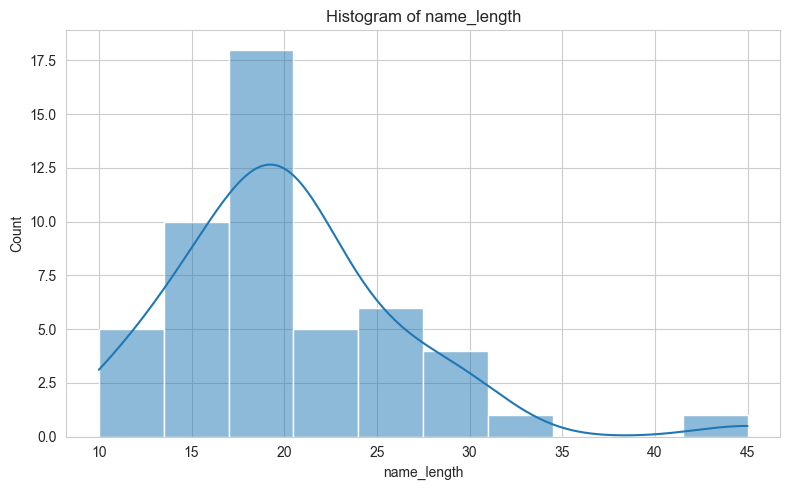

In [28]:
# histogram

for col in numeric_cols[0:1]:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Histogram of {col}")

    plt.tight_layout()

    plt.savefig(f"charts/histogram_{col}.png")

    plt.show()

## Histogram Observations
- Check whether distributions are normal or skewed.
- Long tails indicate skewness.
- Multiple peaks may indicate grouped data.

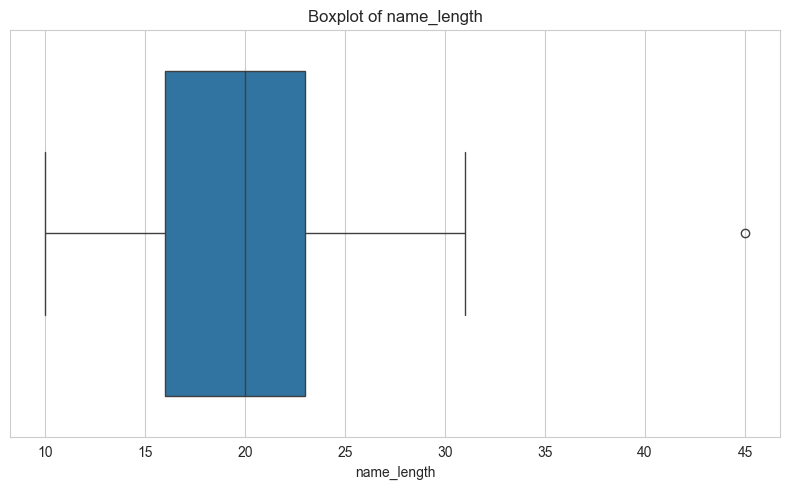

In [29]:
# box plot

for col in numeric_cols[:1]:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()

    plt.savefig(f"charts/boxplot_{col}.png")

    plt.show()

## Boxplot Observations
- Points outside whiskers are possible outliers.
- Large spread indicates high variability.

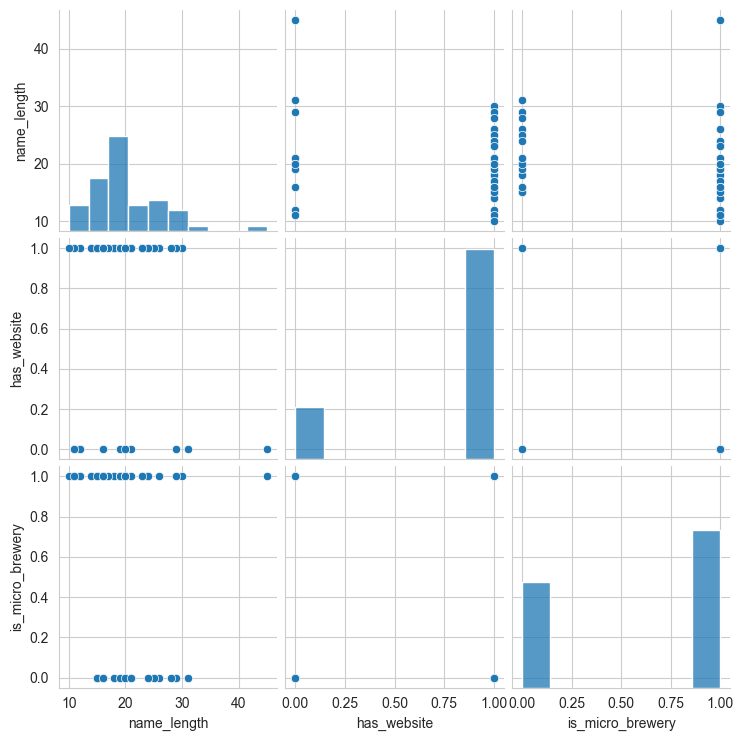

In [30]:
# pair plot

sns.pairplot(df[numeric_cols])

plt.savefig("charts/pairplot.png")

plt.show()

## Pairplot Observations
- Observe relationships between variables.
- Positive trends indicate correlation.
- Scatter randomness may indicate weak relationships.

In [31]:
print("EDA Completed Successfully!")
print("All charts saved inside the 'charts' folder.")

EDA Completed Successfully!
All charts saved inside the 'charts' folder.
